In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import other libraries when needed 

In [3]:
# Load raw data
df = pd.read_parquet("../dataDumper.parquet")

In [4]:
df["Time_utc"] = pd.to_datetime(df["Time_utc"], format='mixed', errors='coerce')
df[['phaseNb']] = df[['RatioPayload']].diff().abs().cumsum()

In [5]:
df = df[["Time_utc", "Latitude_dd", "Longitude_dd", "dt_s", "phaseNb"]]
df

,Time_utc,Latitude_dd,Longitude_dd,dt_s,phaseNb
0,2023-01-01 00:00:00.328,-20.960378,-68.708935,4.912,NaN
1,2023-01-01 00:00:05.338,-20.960730,-68.709170,5.010,0.0
2,2023-01-01 00:00:10.331,-20.961045,-68.709473,4.993,0.0
3,2023-01-01 00:00:15.325,-20.961410,-68.709735,4.994,0.0
4,2023-01-01 00:00:20.448,-20.961828,-68.709977,5.123,0.0
...,...,...,...,...,...
201307,2023-01-14 23:59:40.000,-20.957377,-68.716433,5.000,525.0
201308,2023-01-14 23:59:45.000,-20.957345,-68.716275,5.000,525.0
201309,2023-01-14 23:59:50.000,-20.957320,-68.716098,5.000,525.0
201310,2023-01-14 23:59:55.000,-20.957305,-68.715933,5.000,525.0


In [6]:
dt_s_tolerance = 0.5
original_dt_s = 5
df["missing_record"] = False
df.loc[(df["dt_s"] - original_dt_s).abs() > dt_s_tolerance, "missing_record"] = True

missing_records_df = df[df["missing_record"]].copy()
missing_records_df["nb_missing_records"] = ((missing_records_df["dt_s"] - original_dt_s) / original_dt_s)
df

,Time_utc,Latitude_dd,Longitude_dd,dt_s,phaseNb,missing_record
0,2023-01-01 00:00:00.328,-20.960378,-68.708935,4.912,NaN,False
1,2023-01-01 00:00:05.338,-20.960730,-68.709170,5.010,0.0,False
2,2023-01-01 00:00:10.331,-20.961045,-68.709473,4.993,0.0,False
3,2023-01-01 00:00:15.325,-20.961410,-68.709735,4.994,0.0,False
4,2023-01-01 00:00:20.448,-20.961828,-68.709977,5.123,0.0,False
...,...,...,...,...,...,...
201307,2023-01-14 23:59:40.000,-20.957377,-68.716433,5.000,525.0,False
201308,2023-01-14 23:59:45.000,-20.957345,-68.716275,5.000,525.0,False
201309,2023-01-14 23:59:50.000,-20.957320,-68.716098,5.000,525.0,False
201310,2023-01-14 23:59:55.000,-20.957305,-68.715933,5.000,525.0,False


In [7]:
missing_records_grouped = missing_records_df.groupby(["phaseNb"])["nb_missing_records"].sum()
missing_records_grouped

phaseNb
0.0       7.0356
1.0       0.9894
3.0      11.9820
4.0       6.1922
5.0       0.9982
          ...   
520.0    83.1752
521.0    19.0294
522.0    49.9942
523.0     3.0064
524.0    23.3222
Name: nb_missing_records, Length: 364, dtype: float64

In [8]:
# Nombre total de records par phase
phase_nb_df = pd.DataFrame(df.groupby("phaseNb", as_index=True).size(), columns=["NbRecords"])

# Ajout du nombre de records manquants par phase
phase_nb_df["NbMissingRecords"] = missing_records_grouped
phase_nb_df["NbMissingRecords"].fillna(0, inplace=True)
phase_nb_df["NbMissingRecords"] = phase_nb_df["NbMissingRecords"].astype(int)
phase_nb_df["MissingRate (%)"] = ((phase_nb_df["NbMissingRecords"] / (phase_nb_df["NbMissingRecords"] + phase_nb_df["NbRecords"])) * 100).round(1)

phase_nb_df

,NbRecords,NbMissingRecords,MissingRate (%)
phaseNb,,,
0.0,196,7,3.4
1.0,321,0,0.0
2.0,126,0,0.0
3.0,307,11,3.5
4.0,606,6,1.0
...,...,...,...
521.0,270,19,6.6
522.0,273,49,15.2
523.0,485,3,0.6


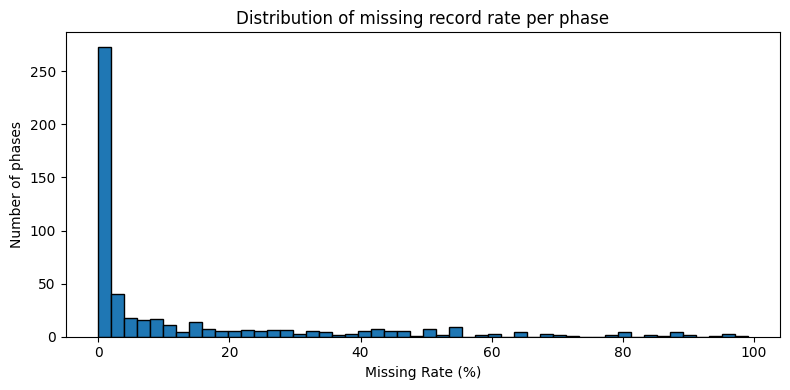

In [9]:
plt.figure(figsize=(8,4))
plt.hist(phase_nb_df["MissingRate (%)"], bins=50, color='tab:blue', edgecolor='black')
plt.xlabel("Missing Rate (%)")
plt.ylabel("Number of phases")
plt.title("Distribution of missing record rate per phase")
plt.tight_layout()
plt.show()

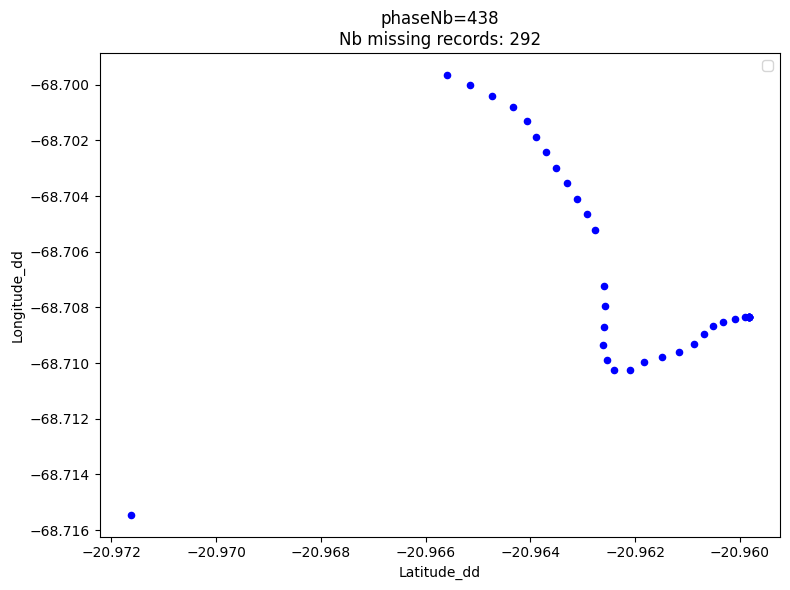

In [ ]:
sorted_phase_nb_df = phase_nb_df.sort_values(by="MissingRate (%)", ascending=False)

from IPython.display import clear_output

phases = sorted_phase_nb_df.index.tolist()

for i, phase_nb in enumerate(phases):
    clear_output(wait=True)
    plt.close('all')
    df_sample = df[df["phaseNb"] == phase_nb]
    nb_missing_records = sorted_phase_nb_df.loc[phase_nb, "NbMissingRecords"]
    fig, ax = plt.subplots(figsize=(8,6))
    ax.scatter(df_sample['Latitude_dd'], df_sample['Longitude_dd'], s=20, c="blue")
    ax.set_title(f"phaseNb={int(phase_nb)}\nNb missing records: {nb_missing_records}")
    ax.set_xlabel("Latitude_dd")
    ax.set_ylabel("Longitude_dd")
    ax.legend()
    plt.tight_layout()
    plt.show()
    if i < len(phases)-1:
        input("Press enter for the next phase...")